In [ ]:
# Import functions from preprocessing.py
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.optim as optim
from tqdm import tqdm


# Add the path to the src directory
sys.path.append(os.path.abspath(os.path.join('..', 'data')))
from generation import generate_data, partition_domain_into_regions

In [2]:
# Import functions from generation.py
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from trainer_debug import trainer, compute_q_phi
from elbo import vi_piX, vi_piS


In [3]:
# Optimising using PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.gaussian_process.kernels import Matern
from scipy.spatial.distance import cdist
import numpy as np
import gpytorch
import torch
import torch.special

def exponential_kernel(X1, X2, length_scale=1.0, sigma=1.0):
    """
    Computes the Matérn covariance function with ν = 1/2 (exponential covariance).

    Args:
        X1 (torch.Tensor): Input tensor of shape (n, d).
        X2 (torch.Tensor): Input tensor of shape (m, d).
        rho (float): Characteristic lengthscale parameter.
        sigma (float): Scaling factor (variance term).

    Returns:
        torch.Tensor: Covariance matrix of shape (n, m).
    """
    dists = torch.cdist(X1, X2, p=2)  # Compute pairwise Euclidean distances
    return sigma * torch.exp(-dists / length_scale)

def compute_regionwise_covariance(s, region_assignments, sigmasq, length_scale, nu=0.5, tausq=1):
    """
    Computes the variance-covariance matrix for the averaged spatial GP process w_ibar.

    Parameters:
    s: (N, 2) tensor of spatial locations
    region_assignments: (N,) tensor assigning each location to a region
    sigma_sq: scalar, variance of the GP
    length_scale: scalar, length scale of the Matern kernel
    nu: scalar, smoothness parameter of the Matern kernel
    tausq: scalar, variance of the noise term

    Returns:
    cov_matrix: (B, B) tensor, variance-covariance matrix of region-averaged w
    """
    unique_regions = torch.unique(region_assignments)
    B = len(unique_regions)
    
    # Compute full covariance matrix for all locations using Matern kernel
    #scaled_s = s / length_scale
    matern_kernel = exponential_kernel(s, s, length_scale=length_scale)
    K = sigmasq * matern_kernel  # Scale by variance
    K += tausq * torch.eye(s.shape[0], device=s.device)  # Add noise term
    
    # Initialize variance-covariance matrix
    cov_matrix = torch.zeros((B, B))
    
    # Create a binary indicator matrix of shape (num_samples, num_regions)
    region_mask = torch.stack([(region_assignments == region).float() for region in unique_regions], dim=1)

    # Compute region sizes (n_i for each region)
    region_sizes = region_mask.sum(dim=0, keepdim=True)  # Shape: (1, num_regions)

    # Compute the covariance matrix efficiently
    # Equivalent to looping over i, j but using matrix multiplication
    region_sums = region_mask.T @ K @ region_mask  # Shape: (num_regions, num_regions)
    cov_matrix = region_sums / (region_sizes.T @ region_sizes)  # Element-wise division

    # # Ensure numerical stability by avoiding division by zero
    # cov_matrix[region_sizes.T @ region_sizes == 0] = 0

    # # Add diagonal tausq / n_i term
    # diag_tau_term = torch.diag(tausq / region_sizes)* torch.eye(B)  # Shape: (num_regions, num_regions)
    # cov_matrix += diag_tau_term
        
    return cov_matrix


# PyTorch Module for optimizing GP parameters
class GPModel(nn.Module):
    def __init__(self, input_dim, device='cpu'):
        super(GPModel, self).__init__()
        self.device = device

        # Learnable parameters
        self.nu = nn.Parameter(torch.tensor(0.5, device=device))
        self.length_scale = nn.Parameter(torch.tensor(1.5, device=device))
        self.tausq = nn.Parameter(torch.tensor(1.0, device=device))
        self.sigmasq = nn.Parameter(torch.tensor(2.0, device=device))
        self.beta = nn.Parameter(torch.zeros(input_dim, device=device))
    
    def GP_log_likelihood(self, y, s, x, beta, K):
        n = y.shape[0]
        K_NN = K  # Use precomputed covariance
        K_NN_noise = K_NN
        log_det = torch.logdet(K_NN_noise)
        
        residual = y - x @ beta
        quadratic_term = residual.T @ torch.linalg.solve(K_NN_noise, residual)
        log_likelihood = -0.5 * (log_det + quadratic_term)
        return log_likelihood   
        

    def forward(self, s, x, y):
        n = y.shape[0]
        # Compute covariance matrix using Matern kernel
        K = self.sigmasq * exponential_kernel(s, s, length_scale=self.length_scale) + self.tausq * torch.eye(n, device=self.device)
        return -self.GP_log_likelihood(y, s, x, self.beta, K)

# PyTorch Module for optimizing block-level covariance
class GPArealModel(nn.Module):
    def __init__(self, input_dim, device='cpu'):
        super(GPArealModel, self).__init__()
        self.device = device

        # Learnable parameters
        self.nu = nn.Parameter(torch.tensor(0.5, device=device))
        self.length_scale = nn.Parameter(torch.tensor(1.5, device=device))
        self.tausq = nn.Parameter(torch.tensor(1.0, device=device))
        self.sigmasq = nn.Parameter(torch.tensor(2.0, device=device))
        self.beta = nn.Parameter(torch.zeros(input_dim, device=device))
    
    def GP_log_likelihood(self, y, s, x, beta, K):
        n = y.shape[0]
        K_NN = K  # Use precomputed covariance
        K_NN_noise = K_NN
        log_det = torch.logdet(K_NN_noise)
        
        residual = y - x @ beta
        quadratic_term = residual.T @ torch.linalg.solve(K_NN_noise, residual)
        log_likelihood = -0.5 * (log_det + quadratic_term)
        return log_likelihood   
        

    def forward(self, s, region_assignments, x, y):
        # Compute covariance matrix using Matern kernel
        K = compute_regionwise_covariance(s, region_assignments, self.sigmasq, self.length_scale, self.nu, self.tausq)
        return -self.GP_log_likelihood(y, s, x, self.beta, K)

```markdown
### Section 1: Generate Spatial Data on B Blocks, Each of Size n

In this section, we generate spatial data for `B` blocks, where each block contains `n` spatial locations. The data includes:

- **Spatial coordinates (`s`)**: Representing the locations within each block.
- **Region assignments (`region_assignments`)**: Assigning each location to a specific region.
- **Response variable (`y`)**: Generated based on a spatial Gaussian process.
- **Covariates (`x`)**: Randomly generated covariates for each location.
- **Random effects (`w`)**: Region-specific random effects.
- **Noise (`e`)**: Independent noise added to the response variable.

The generated data is used for modeling and analysis in subsequent sections. Key parameters include:
- `B`: Number of regions (blocks).
- `n`: Number of locations per region.
- `sigmasq`: Variance of the Gaussian process.
- `length_scale`: Length scale of the spatial kernel.
- `tausq`: Variance of the noise term.
- `beta_true`: True regression coefficient.

The data generation process ensures reproducibility by setting a random seed.
```

In [4]:
B = 100 # Number of regions
n_i = 4 # Number of locations per region
seed_generate = 12224

# Generate data
y, x, w, e, s, region_assignments = generate_data(B, n_i, sigmasq = 5, length_scale=0.25, nu=0.5, seed= seed_generate, beta_true=8, tausq_true=0.25)
# jumbled data generation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = 1
# num_neighbors= 3

y = torch.tensor(y, dtype=torch.float32, device=device)
x = torch.tensor(x, dtype=torch.float32, device=device)
w = torch.tensor(w, dtype=torch.float32, device=device)
e = torch.tensor(e, dtype=torch.float32, device=device)
s = torch.tensor(s, dtype=torch.float32, device=device)
region_assignments = torch.tensor(region_assignments, dtype=torch.int64, device=device)  # Region indices as integers
unique_regions = torch.unique(region_assignments)

```markdown
### Plotting Sampled Locations on the Domain

In this section, we visualize the sampled spatial locations across the `B` blocks. The plot helps verify whether the locations were sampled correctly within the domain. Each block is represented as a grid cell, and the points within each block are plotted with their respective region assignments.
```

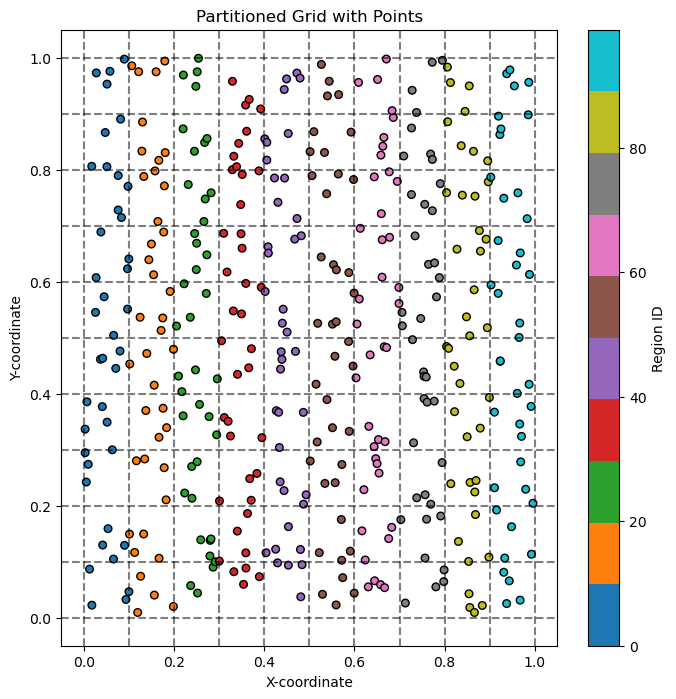

In [5]:
# Plot the grid and points
grid_size = int(np.ceil(np.sqrt(B)))

# Create the plot
plt.figure(figsize=(8, 8))

# Plot the grid
x_divisions = np.linspace(0, 1, grid_size + 1)
y_divisions = np.linspace(0, 1, grid_size + 1)
for xx in x_divisions:
    plt.axvline(x=xx, color='k', linestyle='--', alpha=0.5)
for yy in y_divisions:
    plt.axhline(y=yy, color='k', linestyle='--', alpha=0.5)

# Plot the points
plt.scatter(s[:, 0], s[:, 1], c=region_assignments, cmap='tab10', marker='o', edgecolor='k', s=30)

# Title and labels
plt.title("Partitioned Grid with Points")
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.colorbar(label='Region ID')

plt.show()

```markdown
### Section 2: Fitting the Oracle GP Model

In this section, we fit the oracle Gaussian Process (GP) model using the true `(y, x, s)` tuple. This represents the ideal scenario where the true spatial locations (`s`), covariates (`x`), and response variable (`y`) are known without any permutation. The oracle GP model serves as a benchmark for evaluating the performance of other models under realistic conditions.

```

In [6]:
# Oracle GP model if the locations and links are known
# Initialize and optimize the model
model = GPModel(input_dim, device).to(device)
# optimizer = optim.LBFGS(model.parameters(), lr=0.1, max_iter=100, line_search_fn="strong_wolfe")
optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.01)

for i in tqdm(range(10001)):
    optimizer.zero_grad()
    loss = model(s, x, y)
    loss.backward()
    optimizer.step()
    
    # Constrain sigmasq, length_scale, and tausq to be positive
    with torch.no_grad():
        model.sigmasq.clamp_(min=1e-6)
        model.length_scale.clamp_(min=1e-6)
        model.tausq.clamp_(min=1e-6)
        
    if i % 10000 == 0:
        print(f"Iteration {i}, Loss: {loss.item()}")
        print("nu:", model.nu.item())
        print("length_scale:", model.length_scale.item())
        print("sigma_sq/length_scale:", model.sigmasq.item()/(model.length_scale.item()))
        print("tausq:", model.tausq.item())
        print("sigmasq:", model.sigmasq.item())
        print("beta:", model.beta.detach().cpu().numpy())
        print("=="*20)

  0%|          | 0/10001 [00:00<?, ?it/s]/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_63623/248139798.py:96: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729646995093/work/aten/src/ATen/native/TensorShape.cpp:3687.)
  quadratic_term = residual.T @ torch.linalg.solve(K_NN_noise, residual)
  1%|▏         | 127/10001 [00:00<00:15, 643.13it/s]

Iteration 0, Loss: 1332.3060302734375
nu: 0.5
length_scale: 1.4898500442504883
sigma_sq/length_scale: 1.348994796510865
tausq: 1.0098999738693237
sigmasq: 2.0097999572753906
beta: [0.01]


100%|██████████| 10001/10001 [00:14<00:00, 688.61it/s]

Iteration 10000, Loss: 267.59759521484375
nu: 0.5
length_scale: 0.22389154136180878
sigma_sq/length_scale: 18.873067326575445
tausq: 0.36560317873954773
sigmasq: 4.225520133972168
beta: [7.8499513]


```markdown
### Section 3: Generating Permutated `x` and `s`, and Jumbled Dataset

In this section, we create a permuted version of the covariates (`x`) and spatial locations (`s`) within each region. This involves shuffling the data within regions to simulate a jumbled dataset. The resulting dataset will serve as the input for our analysis.

Key steps include:
- **Permutation of `x` and `s`**: Randomly shuffle the covariates and spatial locations within each region.
- **Jumbled Dataset**: Combine the permuted `x` and `s` to form a dataset with mismatched covariates and locations.

This jumbled dataset introduces a realistic challenge for the analysis, as the true correspondence between `x` and `s` is obscured. The goal is to recover the original structure through modeling and optimization.
```

In [7]:
# Jumble x and s within regions
x_jumbled_within_regions = torch.zeros_like(x)
s_jumbled_within_regions = torch.zeros_like(s)
torch.manual_seed(5556)  # Set a seed for reproducibility
perm_x = torch.randperm(n_i)
perm_s = torch.randperm(n_i)

for i, region in enumerate(unique_regions):
    # Get indices for the current region
    indices = torch.where(region_assignments == region)[0]
    
    # Shuffle the indices within the region
    
    # Assign the shuffled values back
    x_jumbled_within_regions[indices] = x[indices[perm_x]]
    s_jumbled_within_regions[indices] = s[indices[perm_s]]

# Convert perm_s into a permutation matrix
perm_matrix_s = torch.zeros(n_i, n_i, dtype=torch.float32, device=device)
perm_matrix_s[torch.arange(n_i), perm_s] = 1

# Convert perm_x into a permutation matrix
perm_matrix_x = torch.zeros(n_i, n_i, dtype=torch.float32, device=device)
perm_matrix_x[torch.arange(n_i), perm_x] = 1

# Print the permutation matrices
print("Permutation matrix for perm_s:\n", perm_matrix_s)
print("Permutation matrix for perm_x:\n", perm_matrix_x)

Permutation matrix for perm_s:
 tensor([[0., 0., 1., 0.],
        [0., 0., 0., 1.],
        [0., 1., 0., 0.],
        [1., 0., 0., 0.]])
Permutation matrix for perm_x:
 tensor([[0., 0., 1., 0.],
        [1., 0., 0., 0.],
        [0., 0., 0., 1.],
        [0., 1., 0., 0.]])


```markdown
### Section 3.1: Analyzing the Permutated Dataset with GP Areal Model

In this section, we analyze the permutated dataset using the GP Areal model. The key insight is that block-wise aggregates, such as region-wise averages of covariates (`xbar`) and response variables (`ybar`), remain invariant under permutation. This property allows us to effectively model the data even when the original correspondence between covariates and spatial locations is obscured.

#### Key Steps:
1. **Region-wise Aggregation**:
    - Compute the region-wise averages of the permutated covariates (`x_jumbled_within_regions`) and response variables (`y`).
    - These aggregates are represented as `xbar` and `ybar`.

2. **Model Initialization**:
    - Initialize the GP Areal model (`GPArealModel`) with the aggregated data (`xbar`, `ybar`) and spatial locations (`s`).

3. **Optimization**:
    - Optimize the model parameters using gradient-based methods to maximize the likelihood of the observed data.

4. **Analysis**:
    - Evaluate the model's ability to capture the underlying spatial structure and relationships in the permutated dataset.

By leveraging the invariance of block-wise aggregates, the GP Areal model provides a robust framework for analyzing permutated datasets and recovering meaningful insights.
```

In [8]:
# Compute region-wise averages directly
unique_regions = torch.unique(region_assignments)
B = len(unique_regions)

ybar = torch.zeros(B, device=y.device)
xbar = torch.zeros(B, input_dim, device=x.device)

for i, region in enumerate(unique_regions):
    # Get indices for the current region
    indices = torch.where(region_assignments == region)[0]
    
    # Compute region-wise averages for y and x
    ybar[i] = torch.mean(y[indices])
    xbar[i] = torch.mean(x_jumbled_within_regions[indices], dim=0)

# Print results
print("Region-wise y averages (ybar):", ybar)
print("Region-wise x averages (xbar):", xbar)

# Initialize and optimize the model
model = GPArealModel(input_dim, device).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.01)

for i in tqdm(range(8001)):
    optimizer.zero_grad()
    loss = model(s_jumbled_within_regions, region_assignments, xbar, ybar)
    loss.backward()
    optimizer.step()
    
    #with torch.no_grad():
    #     model.length_scale.clamp_(min = .0001)
    #  model.tausq.clamp_(min = .0001)
    #     model.sigmasq.clamp_(min = .0001)
    #     model.nu.clamp_(min = .0001)
        
    if i % 8000 == 0:
        print(f"Iteration {i}, Loss: {loss.item()}")
        print("nu:", model.nu.item())
        print("length_scale:", model.length_scale.item())
        print("sigma_sq/length_scale:", model.sigmasq.item()/(model.length_scale.item()))
        print("tausq:", model.tausq.item())
        print("sigmasq:", model.sigmasq.item())
        print("beta:", model.beta.detach().cpu().numpy())
        print("=="*20)


Region-wise y averages (ybar): tensor([ 2.7972,  7.9724,  0.5199,  5.4199,  9.6612,  4.2104,  3.2916,  2.0763,
         4.2669,  3.0741,  3.7003,  5.7332,  0.9384,  4.8001,  7.9266,  3.6719,
         2.4813,  2.3374,  1.8811,  2.0874,  2.5007,  3.2724,  0.4911,  1.5362,
         4.2304,  0.7671, -0.6088,  0.2751,  0.9919,  0.8912,  5.0269,  2.1068,
         1.4077,  0.8876, -0.3293,  1.0011,  1.0507,  0.4587, -0.9223,  2.7908,
         0.3781,  1.8515,  2.0521,  2.8200, -0.6234,  0.9003, -1.2822,  1.8240,
         0.4035,  3.1436,  2.4328,  1.8248,  1.4730,  1.5019,  3.9293, -2.1442,
        -0.5121,  2.0576,  4.1319,  7.2109,  3.1100,  2.4619,  1.2601,  2.2003,
         5.0678,  0.2389,  2.9822,  5.5467,  4.9928,  2.5135,  1.6290,  3.3531,
         5.3628,  3.5668,  1.4813,  2.0602,  0.9026,  1.6626,  2.7961,  4.4294,
         2.4915,  2.6018,  4.1075,  5.1078,  1.9454,  5.0106,  1.7696,  1.0857,
         1.9105,  2.0813,  4.8653,  4.9041,  5.4363,  5.7563,  5.9259,  5.1879,
         

  1%|          | 85/8001 [00:00<00:09, 845.52it/s]

Iteration 0, Loss: 362.6340026855469
nu: 0.5
length_scale: 1.4898500442504883
sigma_sq/length_scale: 1.348994796510865
tausq: 1.0098999738693237
sigmasq: 2.0097999572753906
beta: [0.01]


100%|██████████| 8001/8001 [00:08<00:00, 901.89it/s]

Iteration 8000, Loss: 56.24530029296875
nu: 0.5
length_scale: 0.2765119969844818
sigma_sq/length_scale: 17.960212338531502
tausq: 0.12823958694934845
sigmasq: 4.966214179992676
beta: [8.671601]


```markdown
### Section 3.2: Fitting the Model with All Locations Using Variational Inference

In this section, we aim to fit the model by leveraging all available spatial locations. The objective is to perform variational inference to simultaneously learn:

1. **Permutations**: Recover the correct correspondence between covariates (`x`) and spatial locations (`s`).
2. **Regression Coefficients (`beta`)**: Estimate the relationship between covariates and the response variable (`y`).
3. **Gaussian Process (GP) Parameters**: Learn the spatial structure of the data, including parameters such as length scale, variance, and noise.

#### Key Steps:
1. **Initialization**:
    - Start with initial estimates for the permutations, `beta`, and GP parameters.
    - Use the jumbled dataset (`x_jumbled_within_regions`, `s_jumbled_within_regions`) as input.

2. **Variational Inference**:
    - Define a variational objective function that incorporates the likelihood of the observed data and a prior over the GP parameters.
    - Optimize the objective function using gradient-based methods.

3. **Learning Permutations**:
    - Iteratively update the permutation matrices for each region to minimize the mismatch between the observed and predicted data.

4. **Parameter Updates**:
    - Update `beta` and GP parameters based on the optimized variational objective.

5. **Evaluation**:
    - Assess the model's ability to recover the true structure of the data and accurately predict the response variable.

This approach provides a robust framework for handling jumbled datasets and extracting meaningful insights from spatial data.
```

In [9]:
n_iter = 100
n_blocks = B
n_locations = n_i

# Random toy data for X and Y
X = torch.tensor(x_jumbled_within_regions, dtype=torch.float32).reshape(n_blocks, n_locations)
Y = torch.tensor(y, dtype=torch.float32).reshape(n_blocks, n_locations)

# Generate (n_blocks * n_locations) 2D coordinates
total_points = n_blocks * n_locations
locations = torch.tensor(s_jumbled_within_regions,dtype=torch.float32)

# Compute distance matrix from locations
Dist = torch.cdist(locations, locations, p=2)  # Pairwise distances

# Set optional args
n_steps = 50
n_phi_samples = 50
n_piX_sample = 50
tau_X = 0.3
tau_S = 0.3
n_piS_sample = 50



print("\n=== Running Minimal Trainer Test ===\n")

results = trainer(
    n_iter=n_iter,
    n_blocks=n_blocks,
    n_locations=n_locations,
    phi_prior_ub=5,
    X=X,
    Y=Y,
    Dist=Dist,
    n_steps=n_steps,
    n_phi_samples=n_phi_samples,
    n_piX_sample=n_piX_sample,
    tau_X=tau_X, tau_S=tau_S,
    n_piS_sample=n_piS_sample,
    seed=521, 
    fix_piX= False, 
    fix_piS= False,
    fix_mu_lambda_beta=False,
    fix_sigmasq_lambda_beta=False,
    fix_lambda_b1=False,
    lambda_b1_fixed=((B*n_i)*0.5 + 0.1) * 5,
    fix_lambda_b2=False,
    M_X_star_fixed=perm_matrix_x.T,
    M_S_star_fixed=perm_matrix_s.T,
    V_X_star_fixed=torch.eye(n_locations, n_locations, device=device),
    V_S_star_fixed=torch.eye(n_locations, n_locations, device=device), 
    phi_init = 0.5,
    mean_Rphi_inv_fixed= torch.linalg.inv(torch.exp(-4 * Dist)),
    fix_mean_Rphi_inv=False, 
    pi_X_true = perm_matrix_x.T,
    pi_S_true = perm_matrix_s.T
)

print("\n=== Final Output ===")
(mu_W, Sigma_W, M_X_star, 
    mean_Rphi_inv, 
    V_X_star, M_S_star, 
    V_S_star, mu_lambda_beta, sigmasq_lambda_beta, lambda_a1, lambda_b1, 
    lambda_a2, lambda_b2) = results



print("\nmu_W:\n", mu_W)
print("\nSigma_W:\n", Sigma_W)
print("\nM_X_star:\n", M_X_star)
print("\nV_X_star:\n", V_X_star)
print("\nM_S_star:\n", M_S_star)
print("\nV_S_star:\n", V_S_star)
print("\nmu_lambda_beta:", mu_lambda_beta)
print("sigmasq_lambda_beta:", sigmasq_lambda_beta)
print("lambda_a1:", lambda_a1, "lambda_b1:", lambda_b1)
print("lambda_a2:", lambda_a2, "lambda_b2:", lambda_b2)



/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_62831/1753814168.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(x_jumbled_within_regions, dtype=torch.float32).reshape(n_blocks, n_locations)
/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_62831/1753814168.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(y, dtype=torch.float32).reshape(n_blocks, n_locations)
/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_62831/1753814168.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTen


=== Running Minimal Trainer Test ===



  0%|          | 0/100 [00:00<?, ?it/s]

Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 1.1921e-07
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 1.1921e-07


  1%|          | 1/100 [00:25<41:32, 25.18s/it]

...

Iter 98/100 | mu_lambda_beta: 7.7080 | 
 sigmasq_lambda_beta: 0.0066 | 
 lambda_a1: 200.1000 | lambda_b1: 609.7417 | lambda_a2: 200.1000 | lambda_b2: 180.0120
‣  E[ϕ]: 4.2667 | ‣ ||mu_W||: 39.4692
Number of correct permutations recognized for piX: 4.0
Number of correct permutations recognized for piS: 4.0
Total Loss: 0.9494
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 2.8658e-03
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 6.5985e-03


 99%|█████████▉| 99/100 [43:58<00:26, 26.26s/it]

Iter 99/100 | mu_lambda_beta: 7.7080 | 
 sigmasq_lambda_beta: 0.0066 | 
 lambda_a1: 200.1000 | lambda_b1: 610.8292 | lambda_a2: 200.1000 | lambda_b2: 180.3739
‣  E[ϕ]: 4.2692 | ‣ ||mu_W||: 39.4873
Number of correct permutations recognized for piX: 4.0
Number of correct permutations recognized for piS: 4.0
Total Loss: 0.9520
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 2.8660e-03
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 7.9461e-03


100%|██████████| 100/100 [44:25<00:00, 26.66s/it]

Iter 100/100 | mu_lambda_beta: 7.7084 | 
 sigmasq_lambda_beta: 0.0066 | 
 lambda_a1: 200.1000 | lambda_b1: 610.6809 | lambda_a2: 200.1000 | lambda_b2: 181.3685
‣  E[ϕ]: 4.2554 | ‣ ||mu_W||: 39.4512
Number of correct permutations recognized for piX: 4.0
Number of correct permutations recognized for piS: 4.0
Total Loss: 0.9523

=== Final Output ===

mu_W:
 tensor([[ 2.5625e-01,  9.6350e-01,  4.5927e-02,  4.6365e-01],
        [ 1.1027e+00,  1.1691e+00,  1.4024e+00,  8.9983e-01],
        [-6.8328e-01, -1.9545e-01, -1.4092e+00, -7.2994e-01],
        [ 1.0274e+00,  1.2722e+00, -4.5178e-03, -4.9786e-01],
        [ 3.2074e+00,  4.0632e+00,  3.4681e+00,  3.9937e+00],
        [ 2.9844e+00,  2.1171e+00,  1.5780e+00,  2.4088e+00],
        [ 1.4285e+00,  1.4917e-01,  9.5928e-01,  1.2363e+00],
        [-1.2524e+00, -1.0366e+00, -1.5103e+00, -1.0579e+00],
        [-7.0074e-01, -1.9571e-01, -1.2889e+00, -3.9333e-01],
        [-1.3094e+00, -9.2399e-01, -1.8668e+00, -1.1772e+00],
        [-1.5172e-01,  

In [ ]:
from scipy.stats import invgamma

Dist= torch.cdist(s_jumbled_within_regions, s_jumbled_within_regions, p=2)
# Define the proposal distribution for phi
phi_proposal = torch.rand(1000) * (10 - (1 / Dist.max())) + (1 / Dist.max())

# Compute the posterior weights (unnormalized)
posterior_weights = torch.tensor([compute_q_phi(phi, Dist, results[1], results[0], results[9], results[10]) for phi in phi_proposal])

# Normalize the weights
posterior_probs = torch.nn.functional.softmax(torch.tensor(posterior_weights), dim=0)

# Perform Sampling Importance Resampling (SIR)
phi_samples = torch.multinomial(posterior_probs, num_samples=1000, replacement=True)

# Resample phi values based on the sampled indices
phi_resampled = phi_proposal[phi_samples]

# Print the resampled phi values
# Print the mean of the resampled phi values
print("Mean of resampled phi values:", phi_resampled.mean().item())
# Calculate E[(R(phi)^(-1))] for resampled phi values
mean_Rphi_inv = torch.mean(torch.stack([torch.linalg.inv(torch.exp(-phi * Dist)) for phi in phi_resampled]), dim=0)

# Print the mean of E[(R(phi)^(-1))]
print("Mean of E[(R(phi)^(-1))]:", torch.norm(mean_Rphi_inv))

# Generate sigma^2 samples from inverse gamma distribution
sigma_sq_samples = invgamma.rvs(results[9], scale=results[10], size=1000)

# Compute sigma^2 * phi for each sample
sigma_sq_phi = sigma_sq_samples * phi_resampled.cpu().numpy()

# Print the mean of sigma^2 * phi
print("Mean of sigma^2 * phi:", sigma_sq_phi.mean())